# PID Control Simulation for Balancing Beam Drone on a Pivot

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))
import random
import matplotlib.pyplot as plt
from core.control_algorthim import PIDController

In [3]:
def run_simulation_loop(dt: float, total_time: float, current_angle: float, target_angle: float, base_throttle: float, arms_length: float, inertia: float, max_integral_error: float = 10.0, kp: float = 0.0, ki: float = 0.0, kd: float = 0.0) -> tuple[list[float], list[float], list[float]]:
    total_steps = int(total_time / dt)
    pid = PIDController(dt=dt, max_integral_error=max_integral_error, kp=kp, ki=ki, kd=kd)
    
    angular_velocity = 0.0
    angular_acceleration = 0.0 

    time_history = []
    target_history = []
    angle_history = []
    
    
    for steps in range(total_steps):
        current_time = steps * dt
        
        sensor_angle = current_angle + random.gauss(0, 0.001)
        
        pid_output = pid.update(target_angle, sensor_angle)
        
        thrust_left = base_throttle - pid_output
        thrust_right = base_throttle + pid_output
        
        thrust_left = pid.clamp(value=thrust_left, min_value=0.0, max_value=15.0)
        thrust_right = pid.clamp(value=thrust_right, min_value=0.0, max_value=15.0)
        
        net_torque = (thrust_right - thrust_left) * arms_length

        angular_acceleration = net_torque / inertia
        angular_velocity += angular_acceleration * dt
        current_angle += angular_velocity * dt
        
        time_history.append(current_time)
        target_history.append(target_angle)
        angle_history.append(current_angle)
        
    return time_history, target_history, angle_history

In [4]:
# Defination the physical characteristic of the drone on a pivot
MASS = 0.5 # 500 grams
LENGTH = 3.0 # meters
ARMS_LENGTH = int(LENGTH / 2) # The length of the drone to the pivot

# Calculation of the moment of inertia of a think rod on a center axis (suspended on a pivot) = I = 1/12 (ML^2)
INERTIA = (1.0 / 12.0) * MASS * (LENGTH ** 2)
BASE_THROTTLE = 5.0 # Base throttle of the drone's propellers to maintain hover state on the pivot
# State of the drone on a pivot, initial simulation configurations

# Definition for time, duration and steps for the PID control loop time
dt = 0.01
total_time = 50.0

# Initial state of the drone on a pivot
current_angle = -25.0 # Initial angle of the drone on the pivot
target_angle = 0.0 # Target angle of the drone on the pivot

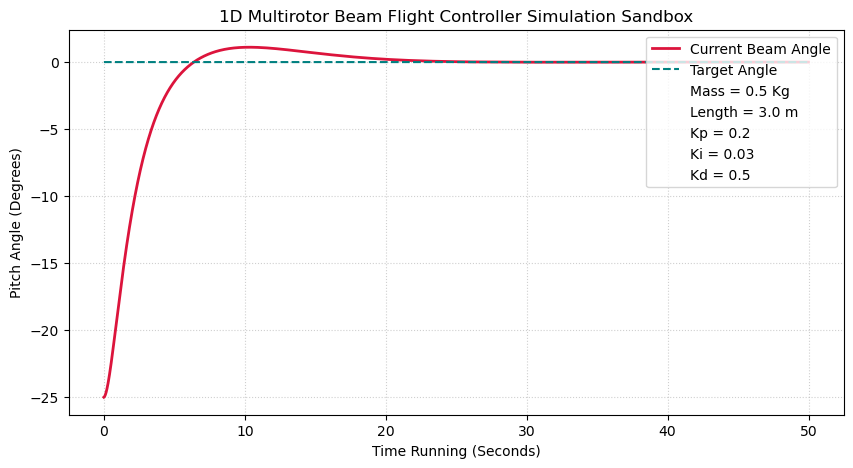

In [5]:
# PID Constants definations, set to zeros initially and adjust or tune later
KP = 0.2
KI = 0.03
KD = 0.5

time_history, target_history, angle_history = run_simulation_loop(dt=dt, total_time=total_time, current_angle=current_angle, target_angle=target_angle, base_throttle=BASE_THROTTLE, arms_length=ARMS_LENGTH, inertia=INERTIA, max_integral_error=10.0, kp=KP, ki=KI, kd=KD)

plt.figure(figsize=(10, 5))
plt.plot(time_history, angle_history, label="Current Beam Angle", color='crimson', linewidth=2)
plt.plot(time_history, target_history, label="Target Angle", color='teal', linestyle='--', linewidth=1.5)

plt.plot([], [], ' ', label=f"Mass = {MASS} Kg")
plt.plot([], [], ' ', label=f"Length = {LENGTH} m")
plt.plot([], [], ' ', label=f"Kp = {KP}")
plt.plot([], [], ' ', label=f"Ki = {KI}")
plt.plot([], [], ' ', label=f"Kd = {KD}")

plt.title("1D Multirotor Beam Flight Controller Simulation Sandbox", fontsize=12)
plt.xlabel("Time Running (Seconds)", fontsize=10)
plt.ylabel("Pitch Angle (Degrees)", fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc="upper right")
plt.show()